# Exploração inicial do WDBC

Este notebook registra uma inspeção acadêmica inicial do dataset Breast Cancer Wisconsin Diagnostic (WDBC) no contexto do Tech Challenge.

O objetivo é observar estrutura, qualidade, distribuição das classes e padrões visuais simples antes de transformar essas características em contrato automatizado.

Este material é acadêmico e não representa validação clínica.

## Importações

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_breast_cancer

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="Set2")

## Carregamento transparente

O dataset é carregado diretamente pelo Scikit-learn, sem usar código de produção do pacote `femhealth`.

In [2]:
dataset = load_breast_cancer(as_frame=True)

X = dataset.data
y = dataset.target.rename("diagnosis")

wdbc = X.copy()
wdbc["diagnosis"] = y

X.shape, y.shape, wdbc.shape

((569, 30), (569,), (569, 31))

## Informações gerais

In [3]:
informacoes_gerais = pd.DataFrame(
    {
        "métrica": ["shape de X", "registros", "features"],
        "valor": [str(X.shape), len(X), X.shape[1]],
    }
)

nomes_classes = pd.DataFrame(
    {
        "código": range(len(dataset.target_names)),
        "classe": ["maligno", "benigno"],
        "nome original": dataset.target_names,
    }
)

nomes_variaveis = pd.DataFrame(
    {"ordem": range(1, len(X.columns) + 1), "variável": X.columns}
)

display(informacoes_gerais)
display(nomes_classes)
display(X.head())
display(nomes_variaveis)

,métrica,valor
0,shape de X,"(569, 30)"
1,registros,569
2,features,30


,código,classe,nome original
0,0,maligno,malignant
1,1,benigno,benign


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,ordem,variável
0,1,mean radius
1,2,mean texture
2,3,mean perimeter
3,4,mean area
4,5,mean smoothness
5,6,mean compactness
6,7,mean concavity
7,8,mean concave points
8,9,mean symmetry
9,10,mean fractal dimension


## Entendimento das variáveis

As features seguem três grupos principais: `mean`, `error` e `worst`. A tabela abaixo organiza os nomes sem acrescentar interpretações médicas além da nomenclatura do próprio dataset.

In [4]:
grupos_variaveis = []

for variavel in X.columns:
    if variavel.startswith("mean "):
        grupo = "mean"
        medida = variavel.removeprefix("mean ")
    elif variavel.endswith(" error"):
        grupo = "error"
        medida = variavel.removesuffix(" error")
    elif variavel.startswith("worst "):
        grupo = "worst"
        medida = variavel.removeprefix("worst ")
    else:
        grupo = "outro"
        medida = variavel

    grupos_variaveis.append({"grupo": grupo, "medida": medida, "variável": variavel})

grupos_variaveis_df = pd.DataFrame(grupos_variaveis)
resumo_grupos = (
    grupos_variaveis_df.groupby("grupo", sort=False)
    .size()
    .reset_index(name="quantidade")
)

descricao_linhas = dataset.DESCR.splitlines()
inicio_atributos = next(
    indice for indice, linha in enumerate(descricao_linhas) if "Attribute Information" in linha
)

print("Trecho da descrição original do dataset:")
print(chr(10).join(descricao_linhas[inicio_atributos : inicio_atributos + 12]))
display(resumo_grupos)
display(grupos_variaveis_df)

Trecho da descrição original do dataset:
:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)



,grupo,quantidade
0,mean,10
1,error,10
2,worst,10


,grupo,medida,variável
0,mean,radius,mean radius
1,mean,texture,mean texture
2,mean,perimeter,mean perimeter
3,mean,area,mean area
4,mean,smoothness,mean smoothness
5,mean,compactness,mean compactness
6,mean,concavity,mean concavity
7,mean,concave points,mean concave points
8,mean,symmetry,mean symmetry
9,mean,fractal dimension,mean fractal dimension


## Qualidade dos dados

A verificação de duplicatas é feita de duas formas: somente nas features `X` e na tabela completa com o target. A diferença importa porque duas linhas com as mesmas features e targets diferentes seriam invisíveis na checagem completa, mas apareceriam na checagem de `X`.

In [5]:
ausentes_por_coluna = wdbc.isna().sum().rename("ausentes")
total_ausentes = int(ausentes_por_coluna.sum())
duplicatas_X = int(X.duplicated().sum())
duplicatas_com_target = int(wdbc.duplicated().sum())

rotulos_classes = {0: "maligno", 1: "benigno"}
distribuicao_classes = (
    y.map(rotulos_classes)
    .value_counts()
    .reindex(["maligno", "benigno"])
    .rename_axis("diagnóstico")
    .reset_index(name="quantidade")
)
distribuicao_classes["percentual"] = distribuicao_classes["quantidade"] / len(y) * 100

resumo_qualidade = pd.DataFrame(
    {
        "métrica": [
            "total de ausentes",
            "duplicatas somente em X",
            "duplicatas com target",
            "classes existentes",
        ],
        "valor": [
            total_ausentes,
            duplicatas_X,
            duplicatas_com_target,
            sorted(y.unique().tolist()),
        ],
    }
)

display(X.dtypes.rename("tipo").to_frame())
display(ausentes_por_coluna.to_frame())
display(resumo_qualidade)
display(distribuicao_classes)

,tipo
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


,ausentes
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


,métrica,valor
0,total de ausentes,0
1,duplicatas somente em X,0
2,duplicatas com target,0
3,classes existentes,"[0, 1]"


,diagnóstico,quantidade,percentual
0,maligno,212,37.258348
1,benigno,357,62.741652


A classe benigna é majoritária. Por isso, em etapas futuras, acurácia não deverá ser analisada isoladamente.

## Estatísticas descritivas

As variáveis estão em escalas diferentes. Isso é relevante para etapas futuras, mas aqui os dados não são padronizados.

In [6]:
estatisticas_descritivas = X.describe().T
estatisticas_descritivas

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## Visualizações

Os gráficos abaixo mostram distribuição das classes, comportamento de algumas features e relações simples com o target.

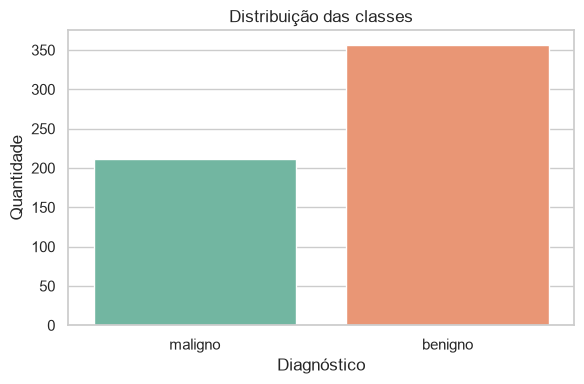

Observação: a classe benigno é majoritária (62.7% dos registros).


In [7]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=distribuicao_classes,
    x="diagnóstico",
    y="quantidade",
    hue="diagnóstico",
    legend=False,
)
plt.title("Distribuição das classes")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

classe_majoritaria = distribuicao_classes.sort_values("quantidade", ascending=False).iloc[0]
print(
    "Observação: a classe "
    f"{classe_majoritaria['diagnóstico']} é majoritária "
    f"({classe_majoritaria['percentual']:.1f}% dos registros)."
)

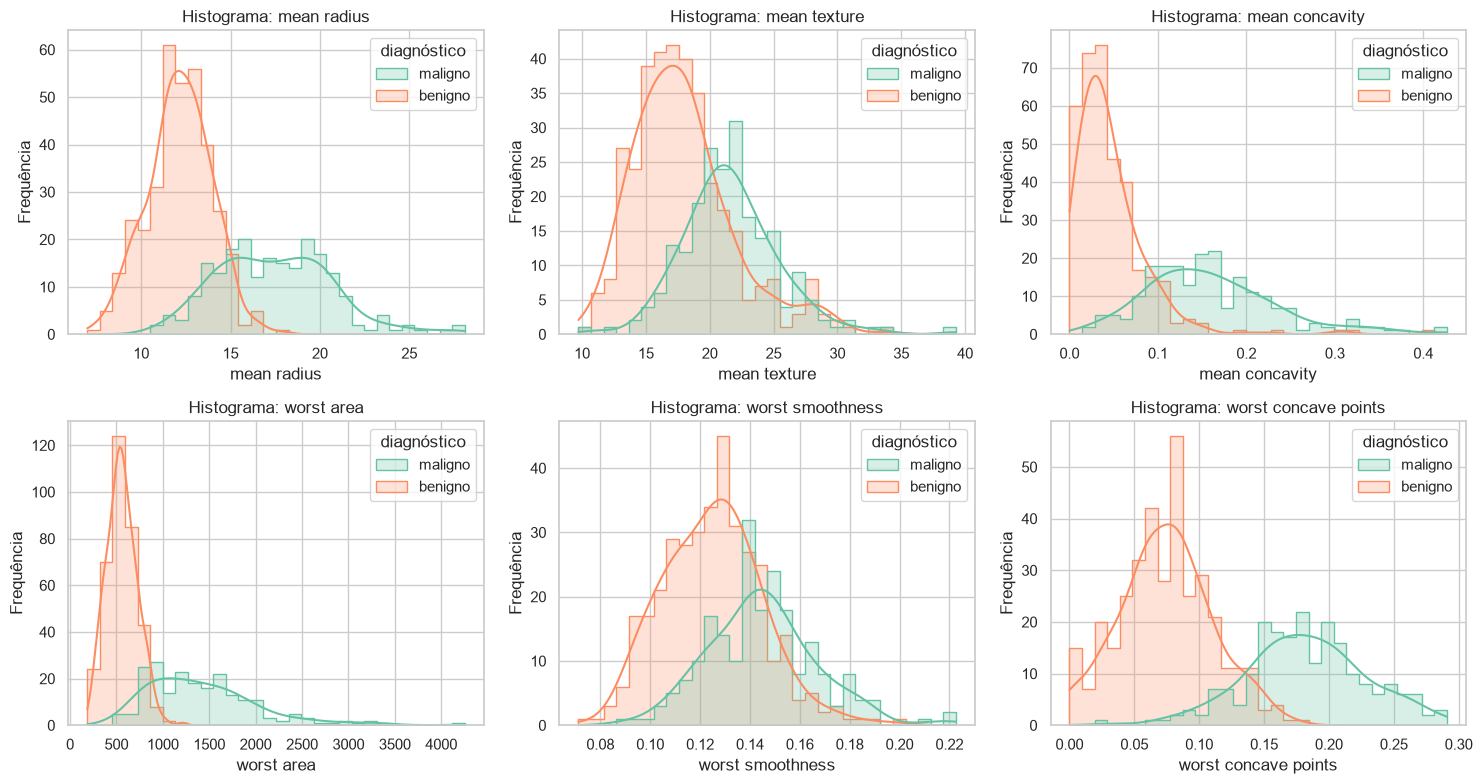

Observação: os histogramas mostram sobreposição entre classes, mas algumas variáveis têm deslocamentos visuais relevantes.


In [8]:
features_representativas = [
    "mean radius",
    "mean texture",
    "mean concavity",
    "worst area",
    "worst smoothness",
    "worst concave points",
]

dados_graficos = wdbc[features_representativas + ["diagnosis"]].copy()
dados_graficos["diagnóstico"] = dados_graficos["diagnosis"].map(rotulos_classes)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for eixo, variavel in zip(axes.ravel(), features_representativas, strict=True):
    sns.histplot(
        data=dados_graficos,
        x=variavel,
        hue="diagnóstico",
        bins=30,
        element="step",
        kde=True,
        ax=eixo,
    )
    eixo.set_title(f"Histograma: {variavel}")
    eixo.set_xlabel(variavel)
    eixo.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

print(
    "Observação: os histogramas mostram sobreposição entre classes, "
    "mas algumas variáveis têm deslocamentos visuais relevantes."
)

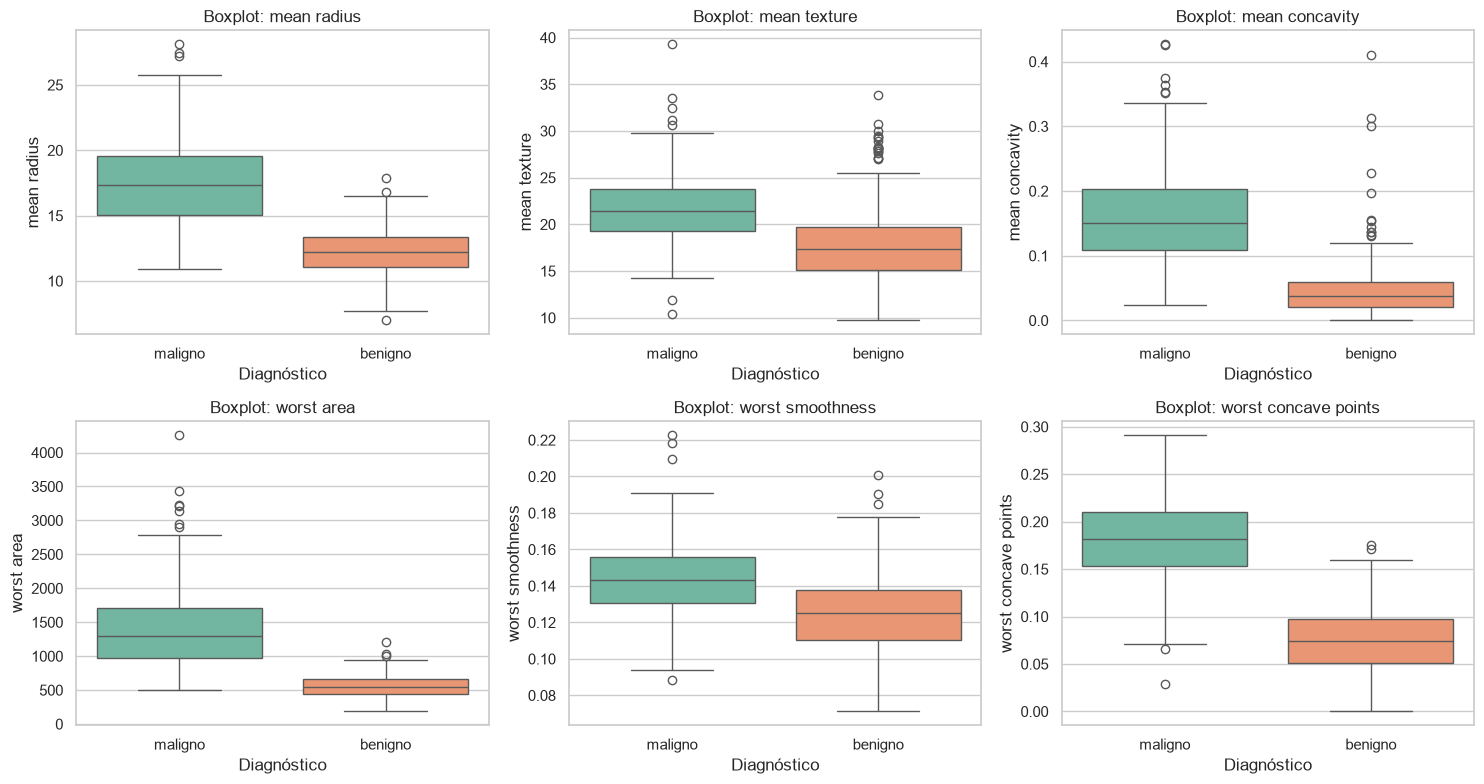

Observação: cada boxplot usa sua própria escala, evitando comparação direta entre variáveis com unidades e amplitudes diferentes.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for eixo, variavel in zip(axes.ravel(), features_representativas, strict=True):
    sns.boxplot(
        data=dados_graficos,
        x="diagnóstico",
        y=variavel,
        hue="diagnóstico",
        legend=False,
        ax=eixo,
    )
    eixo.set_title(f"Boxplot: {variavel}")
    eixo.set_xlabel("Diagnóstico")
    eixo.set_ylabel(variavel)

plt.tight_layout()
plt.show()

print(
    "Observação: cada boxplot usa sua própria escala, evitando comparação direta "
    "entre variáveis com unidades e amplitudes diferentes."
)

## Correlação

O target está codificado como `0 = maligno` e `1 = benigno`. Assim, uma correlação negativa forte indica associação entre valores maiores da feature e a classe codificada como `0`. Correlação não implica causalidade, e features relacionadas podem apresentar multicolinearidade.

,correlação_com_target
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


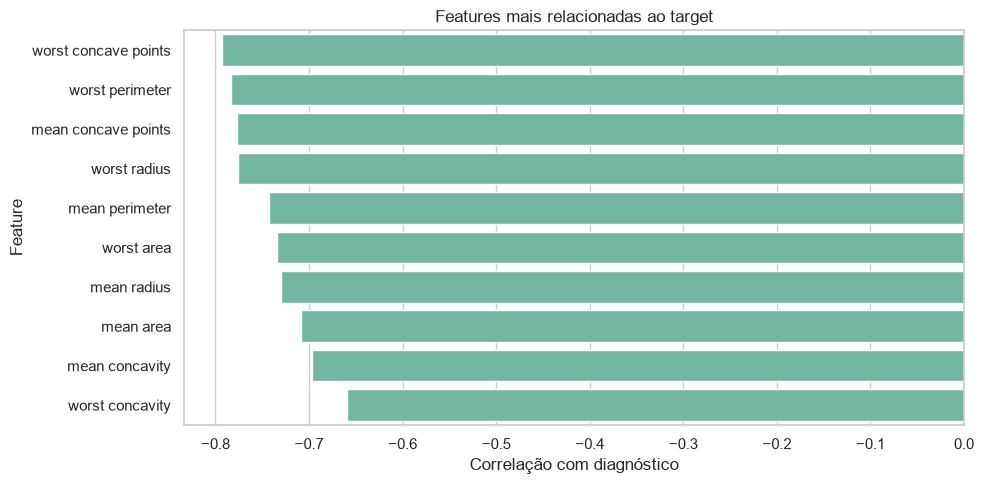

Observação: a maior correlação absoluta observada foi em worst concave points (-0.794).


In [10]:
correlacoes = X.corrwith(y).sort_values(key=lambda valores: valores.abs(), ascending=False)
tabela_correlacoes = correlacoes.rename("correlação_com_target").to_frame()
display(tabela_correlacoes)

principais_correlacoes = tabela_correlacoes.head(10).reset_index(names="feature")

plt.figure(figsize=(10, 5))
sns.barplot(data=principais_correlacoes, x="correlação_com_target", y="feature")
plt.title("Features mais relacionadas ao target")
plt.xlabel("Correlação com diagnóstico")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

mais_relacionada = principais_correlacoes.iloc[0]
print(
    "Observação: a maior correlação absoluta observada foi em "
    f"{mais_relacionada['feature']} ({mais_relacionada['correlação_com_target']:.3f})."
)

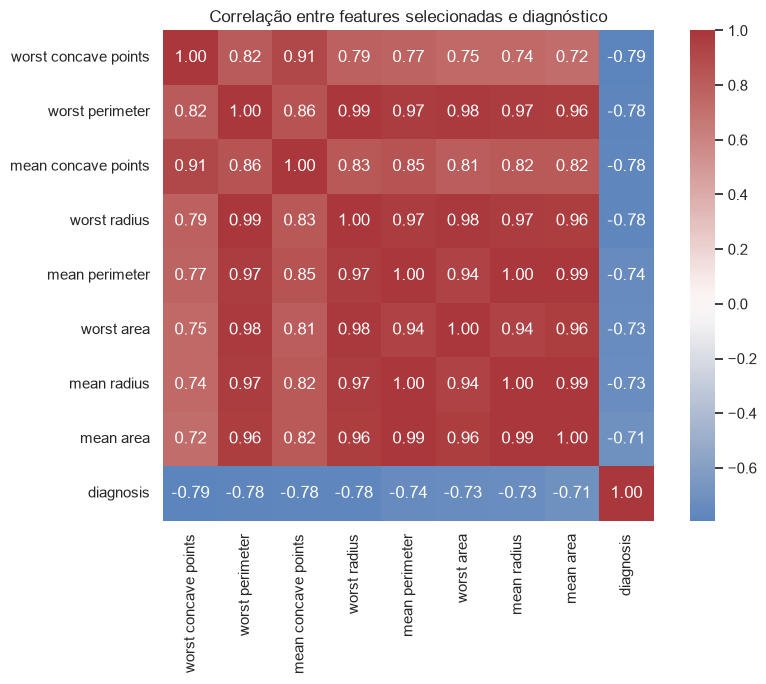

Observação: o heatmap reduzido mantém legibilidade e mostra correlações entre features próximas, sinalizando possível multicolinearidade.


In [11]:
features_heatmap = correlacoes.abs().head(8).index.tolist()
dados_heatmap = wdbc[features_heatmap + ["diagnosis"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(dados_heatmap, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Correlação entre features selecionadas e diagnóstico")
plt.tight_layout()
plt.show()

print(
    "Observação: o heatmap reduzido mantém legibilidade e mostra correlações "
    "entre features próximas, sinalizando possível multicolinearidade."
)

## Conclusões verificadas

As conclusões abaixo são derivadas dos objetos calculados neste notebook.

In [12]:
malignos = int((y == 0).sum())
benignos = int((y == 1).sum())
percentual_benigno = benignos / len(y) * 100
principal_correlacao = principais_correlacoes.iloc[0]

conclusoes = [
    f"Foram observados {len(X)} registros.",
    f"Foram observadas {X.shape[1]} features numéricas.",
    f"A distribuição contém {malignos} casos malignos e {benignos} benignos.",
    f"Não foram encontrados valores ausentes: total = {total_ausentes}.",
    "A análise de duplicatas encontrou "
    f"{duplicatas_X} duplicatas em X e {duplicatas_com_target} na tabela completa.",
    "As estatísticas descritivas mostram diferenças de escala entre as variáveis.",
    f"Há desbalanceamento moderado, com benignos representando {percentual_benigno:.1f}%.",
    "Há correlações relevantes com o target, especialmente em "
    f"{principal_correlacao['feature']}.",
    "Etapas futuras devem considerar pré-processamento e múltiplas métricas de avaliação.",
    "Essas propriedades justificam transformar as descobertas em contrato automatizado.",
]

for conclusao in conclusoes:
    print(f"- {conclusao}")

- Foram observados 569 registros.
- Foram observadas 30 features numéricas.
- A distribuição contém 212 casos malignos e 357 benignos.
- Não foram encontrados valores ausentes: total = 0.
- A análise de duplicatas encontrou 0 duplicatas em X e 0 na tabela completa.
- As estatísticas descritivas mostram diferenças de escala entre as variáveis.
- Há desbalanceamento moderado, com benignos representando 62.7%.
- Há correlações relevantes com o target, especialmente em worst concave points.
- Etapas futuras devem considerar pré-processamento e múltiplas métricas de avaliação.
- Essas propriedades justificam transformar as descobertas em contrato automatizado.
